# Group 91 — MAB Assignment: Adaptive Treatment Recommendation System

**Part #1 — Multi-Armed Bandit (MAB)**  
**Course:** Deep Reinforcement Learning  
**Total Marks:** 5  

---

### Team Contribution Plan
| Member | Responsibility |
|--------|----------------|
| Member 1 | Task 1 — Dataset Design and Environment Setup |
| Member 2 | Task 2 — Immediate Exploitation (Greedy) Strategy |
| Member 3 | Task 3 — Epsilon-Greedy Controlled Clinical Trial |
| Member 4 | Task 4 — UCB1 Confidence-Based Strategy + Task 5 Comparative Analysis |

## Header — Execution Metadata

As required by the assignment, the timestamp and Virtual Machine ID are printed at the top of the notebook.

In [11]:
# ============================================================
# ASSIGNMENT HEADER — Required by assignment specification
# Prints execution timestamp and Virtual Machine ID
# ============================================================
import datetime
import platform
import sys
import os

# Capture execution metadata for submission evidence
GROUP_NUMBER = 91                           # Team / Group number
timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
vm_id = platform.node()                     # Hostname of the virtual machine
python_version = sys.version.split()[0]     # Python version for reproducibility

print("=" * 60)
print("  Deep Reinforcement Learning — Assignment 1 (MAB)")
print("=" * 60)
print(f"  Group Number     : {GROUP_NUMBER}")
print(f"  Execution Time   : {timestamp}")
print(f"  Virtual Machine  : {vm_id}")
print(f"  Python Version   : {python_version}")
print(f"  OS               : {platform.system()} {platform.release()}")
print("=" * 60)

  Deep Reinforcement Learning — Assignment 1 (MAB)
  Group Number     : 91
  Execution Time   : 2026-06-04 19:04:19
  Virtual Machine  : ANTA-GPU-Intel-01
  Python Version   : 3.10.11
  OS               : Windows 10


---
## Task 1 — Dataset Design (1 Mark)

### Problem
A hospital is evaluating multiple medicines for treating a chronic disease where patient responses vary due to hidden factors (age, immunity, genetics, severity). We model each medicine as an **arm** in a Multi-Armed Bandit problem.

### Dataset Rules (Group 91, G = 91)

| Parameter | Formula | Value |
|-----------|---------|-------|
| Number of medicines K | `(G mod 3) + 5` | **6** |
| Hidden probabilities P_i | `0.4 + ((G+i) mod 6) × 0.07` | Computed below |
| Number of patients | Fixed | **1000** |
| Severity score | `(patient_id mod 5) + 1` | 1 (mild) to 5 (critical) |
| Utility reward | `outcome × (1 − severity/10)` | 0.0 to 0.9 |

### Utility Score Interpretation
- Recovered + severity 1 (mild) → reward = **0.9**
- Recovered + severity 5 (critical) → reward = **0.5**  
- Not recovered → reward = **0.0**

In [12]:
# ============================================================
# PARAMETERS (formerly from parameters.py)
# ============================================================
"""Shared assignment parameters derived from the group number."""

GROUP_NUMBER = 91
LAST_DIGIT = GROUP_NUMBER % 10

# MAB derived parameters
MAB_NUM_MEDICINES = (GROUP_NUMBER % 3) + 5
MAB_HIDDEN_PROBS = [0.4 + ((GROUP_NUMBER + i) % 6) * 0.07 for i in range(MAB_NUM_MEDICINES)]
MAB_NUM_PATIENTS = 1000

# DP derived parameters
DP_GRID_SIZE = 6 if LAST_DIGIT >= 5 else 5
DP_MAX_BATTERY = 15 if LAST_DIGIT % 2 == 1 else 10
DP_WIND_PROB = 0.30 if LAST_DIGIT >= 5 else 0.20
DP_MAX_STEPS = 75 if DP_GRID_SIZE == 6 else 50
DP_NUM_RESCUE = 2 if LAST_DIGIT <= 4 else 3
DP_NUM_CHARGERS = 1 if LAST_DIGIT <= 4 else 2
DP_NUM_DANGER = 3 if LAST_DIGIT <= 4 else 4
DP_NUM_BLOCKED = 2 if LAST_DIGIT <= 4 else 3

# Environment type indicators
MAB_ENV_NAME = "Multi-Armed Bandit"
DP_ENV_NAME = "Drone Rescue DP"

# Feature toggles
MAB_ENABLED = 1
DP_ENABLED = 1


In [13]:
# ============================================================
# DATASET MODULE (formerly from mab/dataset.py)
# ============================================================
"""
Synthetic Patient Dataset for Multi-Armed Bandit Assignment (Group 91).

This module creates a reproducible synthetic patient-treatment dataset
following the exact rules from the assignment specification:
  - Group number G = 91 drives all derived parameters.
  - Both Python random and NumPy random seeds are set to G for reproducibility.
  - Patient severity scores cycle from 1 (mild) to 5 (critical).
  - Utility rewards scale with clinical outcome and decrease with higher severity.
"""

import random
import numpy as np
import pandas as pd
# GROUP_NUMBER and MAB_NUM_PATIENTS defined above


def create_patient_dataset(group_number: int = GROUP_NUMBER, n_patients: int = MAB_NUM_PATIENTS):
    """Create the synthetic MAB patient dataset according to assignment rules.

    The dataset encodes 1000 patients, each with a severity score and placeholder
    columns (assigned_medicine, clinical_outcome, utility_score) that are populated
    dynamically during algorithm execution.

    Derivation rules (Section 1 of assignment):
      - K = (G mod 3) + 5         → number of medicines (arms)
      - P_i = 0.4 + ((G+i) mod 6) * 0.07  → hidden success probability per medicine
      - Severity = (patient_id mod 5) + 1  → ranges 1 (mild) to 5 (critical)

    Args:
        group_number (int): Team group number used as random seed and for deriving
                            all dataset parameters. Default is GROUP_NUMBER from
                            parameters.py (91).
        n_patients (int): Number of synthetic patients to generate (default 1000).

    Returns:
        tuple:
            - dataset (pd.DataFrame): Patient records with columns:
                patient_id, severity_score, assigned_medicine,
                clinical_outcome, utility_score.
            - metadata (dict): Keys 'group_number', 'n_medicines', 'hidden_probs'.
    """
    # --- Reproducibility: seed BOTH Python random and NumPy as required ---
    random.seed(group_number)         # Seed Python's built-in random module
    np.random.seed(group_number)      # Seed NumPy's random module

    # Rule 1.1: Number of medicines (arms)
    k_medicines = (group_number % 3) + 5

    # Rule 1.2: Hidden success probability for each medicine i in {0,...,K-1}
    hidden_probs = [
        0.4 + ((group_number + i) % 6) * 0.07
        for i in range(k_medicines)
    ]

    # Generate patient IDs and compute severity scores (Rule 1.3)
    patient_ids = np.arange(n_patients)
    # Severity cycles 1,2,3,4,5,1,2,... using modulo arithmetic
    severity_scores = (patient_ids % 5) + 1

    # Build the base dataset; algorithm columns start as placeholders (-1 / 0.0)
    dataset = pd.DataFrame(
        {
            "patient_id": patient_ids,
            "severity_score": severity_scores,
            "assigned_medicine": -1,    # Populated during algorithm execution
            "clinical_outcome": -1,     # Binary: 1=Recovered, 0=Not Recovered
            "utility_score": 0.0,       # Reward used for cumulative reward tracking
        }
    )

    metadata = {
        "group_number": group_number,
        "n_medicines": k_medicines,
        "hidden_probs": hidden_probs,
    }
    return dataset, metadata


def compute_reward(clinical_outcome: int, severity_score: int) -> float:
    """Compute the utility reward for a patient based on outcome and disease severity.

    Formula (Rule 1.3):
        UtilityScore = clinical_outcome × (1 - severity / 10)

    Interpretation:
        - Recovered (outcome=1), severity=1 (mild)     → reward = 0.9
        - Recovered (outcome=1), severity=5 (critical) → reward = 0.5
        - Not recovered (outcome=0)                     → reward = 0.0

    Treatment benefit decreases for severely ill patients because clinical
    success has reduced real-world impact when baseline health is critical.

    Args:
        clinical_outcome (int): 1 if patient recovered, 0 otherwise.
        severity_score (int): Disease severity in range [1, 5].

    Returns:
        float: Utility reward value in [0.0, 0.9].
    """
    return float(clinical_outcome) * (1.0 - 0.1 * severity_score)


In [14]:
# ============================================================
# ENVIRONMENT MODULE (formerly from mab/environment.py)
# ============================================================
"""
Reusable Multi-Armed Bandit (MAB) Environment Wrapper (Group 91).

This module defines the MABEnvironment class that simulates the clinical trial
bandit problem. The environment tracks which medicine (arm) is assigned to each
patient, the binary clinical outcome, and the utility score used as the reward.

Key design decisions:
  - Hidden success probabilities are fixed per medicine (arm) and unknown to algorithms.
  - Each call to step() advances exactly one patient (one time step).
  - Arms are tracked with pulls, successes, and total accumulated reward.
  - Utility score (not raw outcome) is used to compute cumulative reward, as it
    accounts for patient severity.
"""

from typing import Dict, List, Tuple
import numpy as np
import pandas as pd
# compute_reward function defined above in dataset module


class MABEnvironment:
    """Bandit environment that tracks arm pulls, rewards, and patient assignments.

    This environment models a hospital clinical trial where each medicine is an
    arm with a fixed but hidden success probability. At each time step (patient),
    the algorithm selects an arm (medicine). The environment samples the clinical
    outcome stochastically based on the arm's hidden probability, computes the
    utility reward (penalised for high severity), and records everything in the
    dataset.

    Attributes:
        hidden_probs (List[float]): True success probabilities for each arm.
        dataset (pd.DataFrame): Patient dataset with outcome columns.
        n_arms (int): Number of available medicines (arms).
        pulls (np.ndarray): Count of how many times each arm has been pulled.
        total_rewards (np.ndarray): Accumulated utility reward per arm.
        successes (np.ndarray): Count of successful (recovered) outcomes per arm.
        current_step (int): Index of the current patient being treated.
    """

    def __init__(self, hidden_probs: List[float], dataset: pd.DataFrame):
        """Initialise the MAB environment with given arm probabilities and patient data.

        Args:
            hidden_probs (List[float]): Hidden success probability P_i for each arm i.
            dataset (pd.DataFrame): Patient dataset created by create_patient_dataset().
        """
        self.hidden_probs = hidden_probs
        self.dataset = dataset.copy()   # Work on a copy to avoid mutating the original
        self.n_arms = len(hidden_probs)
        self.reset()

    def reset(self):
        """Reset the environment to its initial state for a fresh algorithm run.

        Clears all assignment columns back to placeholders and resets all arm
        statistics (pulls, rewards, successes) and the step counter. Must be called
        before starting any new strategy simulation.
        """
        # Reset dataset assignment columns
        self.dataset["assigned_medicine"] = -1
        self.dataset["clinical_outcome"] = -1
        self.dataset["utility_score"] = 0.0

        # Reset arm-level statistics
        self.pulls = np.zeros(self.n_arms, dtype=int)           # Pull counts per arm
        self.total_rewards = np.zeros(self.n_arms, dtype=float) # Accumulated reward
        self.successes = np.zeros(self.n_arms, dtype=int)       # Recovery counts
        self.current_step = 0                                    # Patient index

    def step(self, arm: int) -> Tuple[int, float]:
        """Assign the selected medicine (arm) to the current patient and get reward.

        Samples a binary clinical outcome from the arm's hidden Bernoulli distribution,
        computes the severity-adjusted utility score, updates arm statistics, and
        records the results in the dataset.

        Args:
            arm (int): Index of the selected medicine (0 to n_arms-1).

        Returns:
            tuple:
                - outcome (int): 1 if the patient recovered, 0 otherwise.
                - reward (float): Utility score = outcome × (1 - 0.1 × severity).
        """
        # Fetch current patient's severity score
        patient = self.dataset.loc[self.current_step]
        severity = int(patient["severity_score"])

        # Sample clinical outcome from the arm's hidden Bernoulli distribution
        outcome = int(np.random.rand() < self.hidden_probs[arm])

        # Compute severity-adjusted utility reward (lower reward for severe patients)
        reward = compute_reward(outcome, severity)

        # Update arm-level statistics
        self.pulls[arm] += 1
        self.total_rewards[arm] += reward
        self.successes[arm] += outcome

        # Record this step's results into the dataset
        self.dataset.at[self.current_step, "assigned_medicine"] = arm
        self.dataset.at[self.current_step, "clinical_outcome"] = outcome
        self.dataset.at[self.current_step, "utility_score"] = reward

        self.current_step += 1
        return outcome, reward

    def get_average_rewards(self) -> np.ndarray:
        """Compute average utility reward per arm across all pulls so far.

        Arms that have never been pulled return 0.0 (safe division via numpy).

        Returns:
            np.ndarray: Average reward for each arm (shape: [n_arms]).
        """
        return np.divide(
            self.total_rewards,
            self.pulls,
            out=np.zeros_like(self.total_rewards),
            where=self.pulls > 0,
        )

    def get_success_rates(self) -> np.ndarray:
        """Compute empirical success rate (recovery proportion) per arm.

        Returns:
            np.ndarray: Empirical recovery rate for each arm (shape: [n_arms]).
        """
        return np.divide(
            self.successes.astype(float),
            self.pulls,
            out=np.zeros_like(self.total_rewards),
            where=self.pulls > 0,
        )

    def get_cumulative_reward(self) -> float:
        """Return the total accumulated utility reward across all treated patients.

        Returns:
            float: Sum of utility_score column for all steps taken so far.
        """
        return float(self.dataset["utility_score"].sum())

    def get_current_step(self) -> int:
        """Return the index of the next patient to be treated.

        Returns:
            int: Current step index (0-indexed patient ID).
        """
        return int(self.current_step)

    def get_arm_summary(self) -> Dict[int, dict]:
        """Return a per-arm summary of pulls, success rate, and average reward.

        Useful for post-run analysis to see which arm dominated selection.

        Returns:
            dict: Keys are arm indices; values are dicts with 'pulls',
                  'success_rate', 'avg_reward'.
        """
        avg_rewards = self.get_average_rewards()
        success_rates = self.get_success_rates()
        summary = {}
        for i in range(self.n_arms):
            summary[i] = {
                "pulls": int(self.pulls[i]),
                "success_rate": round(float(success_rates[i]), 4),
                "avg_reward": round(float(avg_rewards[i]), 4),
            }
        return summary


In [15]:
# ============================================================
# STRATEGIES MODULE (formerly from mab/strategies.py)
# ============================================================
"""
Bandit Strategy Implementations for MAB Assignment (Group 91).

This module implements three exploration-exploitation strategies for the
Multi-Armed Bandit clinical trial problem:

  1. Greedy (Immediate Exploitation): Test each arm briefly, then always exploit
     the best-performing arm. No further exploration after the initial phase.

  2. Epsilon-Greedy (Controlled Exploration): With probability ε explore a random
     arm; otherwise exploit the current best arm. Supports ε ∈ {0.01, 0.10, 0.50}.

  3. UCB1 (Confidence-Based Selection): Select arms based on their upper confidence
     bound — initially favouring under-explored arms; confidence shrinks as
     evidence grows, naturally balancing exploration and exploitation.

Each strategy returns:
  - The updated MABEnvironment (with dataset populated).
  - A history dictionary containing per-step records for analysis.
"""

from typing import Dict, List, Tuple
import numpy as np
# MABEnvironment class defined above in environment module


# Type alias for strategy result histories
StrategyHistory = Dict[str, List]


def greedy_strategy(
    env: MABEnvironment,
    initial_pulls: int = 10,
) -> Tuple[MABEnvironment, StrategyHistory]:
    """Run the Immediate Exploitation (Greedy) strategy over all 1000 patients.

    Strategy logic (Task 2):
      Phase 1 – Exploration: Each arm is pulled exactly `initial_pulls` times in
                round-robin order, cycling through arm 0, 1, ..., K-1. This gives
                the algorithm minimal evidence to estimate each arm's effectiveness.
      Phase 2 – Exploitation: Once all arms have been tested `initial_pulls` times,
                the arm with the highest average utility reward is selected for ALL
                remaining patients. No further exploration occurs.

    This reflects the hospital administrator's "use the best known treatment" policy.

    Args:
        env (MABEnvironment): Bandit environment to simulate.
        initial_pulls (int): Number of initial pulls per arm before exploitation.
                             Default is 10 (so 60 exploration steps for 6 arms).

    Returns:
        tuple:
            - env (MABEnvironment): Environment with dataset fully populated.
            - history (dict): Contains:
                'cumulative_reward': list of cumulative reward after each step.
                'selected_arm': list of arm chosen at each step.
                'phase': list of 'explore' or 'exploit' tag per step.
    """
    history = {
        "cumulative_reward": [],
        "selected_arm": [],
        "phase": [],
    }
    env.reset()   # Clear previous run data before starting

    # Total exploration steps = number of arms × pulls per arm
    exploration_end = env.n_arms * initial_pulls

    for t in range(len(env.dataset)):
        if t < exploration_end:
            # --- Phase 1: Exploration ---
            # Cycle through arms sequentially: arm = t // initial_pulls
            # e.g., with initial_pulls=10 and 6 arms:
            #   t=0..9 → arm 0, t=10..19 → arm 1, ..., t=50..59 → arm 5
            arm = t // initial_pulls
            phase = "explore"
        else:
            # --- Phase 2: Exploitation ---
            # Always select the arm with the highest average utility reward
            arm = int(np.argmax(env.get_average_rewards()))
            phase = "exploit"

        # Execute the chosen arm on the current patient
        env.step(arm)

        # Record step-level history
        history["cumulative_reward"].append(env.get_cumulative_reward())
        history["selected_arm"].append(arm)
        history["phase"].append(phase)

    return env, history


def epsilon_greedy_strategy(
    env: MABEnvironment,
    epsilon: float,
    initial_pulls: int = 1,
) -> Tuple[MABEnvironment, StrategyHistory]:
    """Run the Epsilon-Greedy Controlled Exploration strategy over 1000 patients.

    Strategy logic (Task 3):
      At each time step, a Bernoulli draw with probability ε decides the action:
        - With probability ε  → Explore: select a uniformly random arm.
        - With probability 1-ε → Exploit: select the arm with the highest
                                  average utility reward so far.
      If any arm has never been pulled yet, it is selected first (ensures
      each arm gets at least one observation before exploitation begins).

    The ε parameter controls the exploration-exploitation tradeoff:
        ε = 0.01  → aggressive exploitation, minimal exploration
        ε = 0.10  → balanced (recommended clinical default)
        ε = 0.50  → heavy exploration, slow convergence

    Args:
        env (MABEnvironment): Bandit environment to simulate.
        epsilon (float): Exploration probability in [0, 1].
        initial_pulls (int): Min pulls per arm before pure greedy kicks in.
                             Default 1 ensures every arm is tried at least once.

    Returns:
        tuple:
            - env (MABEnvironment): Environment with dataset fully populated.
            - history (dict): Contains:
                'cumulative_reward': cumulative reward after each step.
                'selected_arm': arm chosen at each step.
                'action_type': 'explore' or 'exploit' for each step.
                'epsilon': constant epsilon value (recorded for reference).
    """
    history = {
        "cumulative_reward": [],
        "selected_arm": [],
        "action_type": [],
        "epsilon": epsilon,   # Store scalar, not per-step list
    }
    env.reset()   # Clear previous run data before starting

    for t in range(len(env.dataset)):
        # Ensure every arm is tried at least once before greedy exploitation
        if np.any(env.pulls == 0):
            # Find the first arm that hasn't been pulled yet
            arm = int(np.argmin(env.pulls))
            action_type = "init_explore"

        elif np.random.rand() < epsilon:
            # --- Exploration: random arm selection ---
            arm = int(np.random.choice(env.n_arms))
            action_type = "explore"

        else:
            # --- Exploitation: choose arm with highest average utility reward ---
            arm = int(np.argmax(env.get_average_rewards()))
            action_type = "exploit"

        # Execute the chosen arm on the current patient
        env.step(arm)

        # Record step-level history
        history["cumulative_reward"].append(env.get_cumulative_reward())
        history["selected_arm"].append(arm)
        history["action_type"].append(action_type)

    return env, history


def ucb1_strategy(env: MABEnvironment) -> Tuple[MABEnvironment, StrategyHistory]:
    """Run the UCB1 (Upper Confidence Bound) Confidence-Based strategy over 1000 patients.

    Strategy logic (Task 4):
      UCB1 selects the arm with the highest Upper Confidence Bound score:

          UCB1(i, t) = avg_reward(i) + sqrt( 2 * ln(t) / pulls(i) )

      Where:
        - avg_reward(i) : exploitation term — how good arm i appears to be.
        - sqrt(2*ln(t)/pulls(i)) : exploration bonus — shrinks as arm i is pulled
                                    more, ensuring under-explored arms are favoured.

      Interpretation for the senior physician (Task 4 scenario):
        - Arms with fewer pulls have a larger exploration bonus, giving them more
          chances initially.
        - As evidence grows for each arm, the bonus shrinks and exploitation
          dominates — the algorithm naturally converges to the best arm.

      Initialisation: pull each arm exactly once before applying UCB1 scores
      (prevents division by zero in the confidence term).

    Args:
        env (MABEnvironment): Bandit environment to simulate.

    Returns:
        tuple:
            - env (MABEnvironment): Environment with dataset fully populated.
            - history (dict): Contains:
                'cumulative_reward': cumulative reward after each step.
                'selected_arm': arm chosen at each step.
                'ucb_scores': UCB1 score vector at each step (for analysis).
    """
    history = {
        "cumulative_reward": [],
        "selected_arm": [],
        "ucb_scores": [],
    }
    env.reset()   # Clear previous run data before starting

    for t in range(len(env.dataset)):
        if t < env.n_arms:
            # --- Initialisation phase: pull each arm once to avoid zero pulls ---
            # Arm selected in round-robin: arm 0, 1, ..., K-1
            arm = t
            ucb_scores = None
        else:
            # --- UCB1 selection: pick arm maximising upper confidence bound ---
            avg = env.get_average_rewards()             # Exploitation term
            # Exploration bonus: sqrt(2 * ln(t+1) / pulls[i]) per arm
            confidence = np.sqrt(2.0 * np.log(t + 1) / env.pulls)
            ucb_scores = avg + confidence               # Combined UCB1 score

            # Select the arm with the highest UCB1 score
            arm = int(np.argmax(ucb_scores))

        # Execute the chosen arm on the current patient
        env.step(arm)

        # Record step-level history
        history["cumulative_reward"].append(env.get_cumulative_reward())
        history["selected_arm"].append(arm)
        history["ucb_scores"].append(
            ucb_scores.tolist() if ucb_scores is not None else None
        )

    return env, history


In [16]:
# ============================================================
# ANALYSIS MODULE (formerly from mab/analysis.py)
# ============================================================
"""
Analysis and Plotting Utilities for MAB Assignment (Group 91).

This module provides functions to visualise and compare the performance of
different Multi-Armed Bandit strategies:

  - plot_cumulative_rewards : styled line chart comparing all strategies.
  - plot_epsilon_comparison  : sub-plot comparing epsilon-greedy variants.
  - summarize_results        : tabular summary of final cumulative rewards.
  - print_comparison_answers : formatted printed answers to Task 5 questions.
"""

from typing import Dict, List, Optional
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Consistent colour palette for strategies across all plots
STRATEGY_COLORS = {
    "Immediate Exploitation (Greedy)": "#E63946",
    "Epsilon-Greedy 1%":               "#457B9D",
    "Epsilon-Greedy 10%":              "#2A9D8F",
    "Epsilon-Greedy 50%":              "#F4A261",
    "UCB1":                            "#6A0572",
}

STRATEGY_LINESTYLES = {
    "Immediate Exploitation (Greedy)": "--",
    "Epsilon-Greedy 1%":               "-.",
    "Epsilon-Greedy 10%":              "-",
    "Epsilon-Greedy 50%":              ":",
    "UCB1":                            "-",
}


def plot_cumulative_rewards(
    history_map: Dict[str, List[float]],
    title: str = "Cumulative Reward vs Number of Patients (Group 91)",
    save_path: Optional[str] = None,
):
    """Plot cumulative reward curves for all MAB strategies on a single figure.

    Each strategy is drawn as a distinct coloured line with a matching linestyle.
    Dashed vertical annotation marks the end of the Greedy exploration phase (60
    patients = 6 arms × 10 initial pulls).

    Args:
        history_map (Dict[str, List[float]]): Strategy name → list of cumulative
            rewards (one value per patient step, length 1000).
        title (str): Plot title.
        save_path (Optional[str]): If provided, saves the figure to this filepath
            instead of (or in addition to) displaying it inline.
    """
    fig, ax = plt.subplots(figsize=(13, 7))

    # --- Draw one line per strategy ---
    for label, rewards in history_map.items():
        color = STRATEGY_COLORS.get(label, "#333333")
        ls    = STRATEGY_LINESTYLES.get(label, "-")
        ax.plot(
            range(1, len(rewards) + 1),
            rewards,
            label=label,
            color=color,
            linestyle=ls,
            linewidth=2.2,
        )

    # --- Vertical marker: end of Greedy exploration phase ---
    ax.axvline(
        x=60, color="grey", linestyle=":", linewidth=1.2,
        label="Greedy exploration ends (patient 60)"
    )

    # --- Axes formatting ---
    ax.set_xlabel("Number of Patients Treated", fontsize=13, labelpad=8)
    ax.set_ylabel("Cumulative Utility Reward", fontsize=13, labelpad=8)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=14)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    ax.legend(fontsize=10, loc="upper left", framealpha=0.9)
    ax.grid(True, which="major", linestyle="--", alpha=0.4)
    ax.set_xlim(1, len(next(iter(history_map.values()))))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")
    plt.show()


def plot_epsilon_comparison(
    epsilon_histories: Dict[str, List[float]],
    save_path: Optional[str] = None,
):
    """Plot a three-panel comparison of epsilon-greedy variants (1%, 10%, 50%).

    Three sub-plots share the x-axis for easy comparison of how different
    exploration rates affect the cumulative reward trajectory.

    Args:
        epsilon_histories (Dict[str, List[float]]): Maps epsilon label to
            cumulative reward list. Expected keys: 'Epsilon-Greedy 1%',
            'Epsilon-Greedy 10%', 'Epsilon-Greedy 50%'.
        save_path (Optional[str]): Optional filepath to save the figure.
    """
    labels = list(epsilon_histories.keys())
    colors = ["#457B9D", "#2A9D8F", "#F4A261"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    fig.suptitle(
        "Epsilon-Greedy Strategy: Effect of Exploration Rate (Group 91)",
        fontsize=13, fontweight="bold"
    )

    for ax, label, color in zip(axes, labels, colors):
        rewards = epsilon_histories[label]
        ax.plot(range(1, len(rewards) + 1), rewards, color=color, linewidth=2)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel("Patients Treated", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)
        # Annotate final cumulative reward
        final = rewards[-1]
        ax.annotate(
            f"Final: {final:.2f}",
            xy=(len(rewards), final),
            xytext=(-80, -20),
            textcoords="offset points",
            fontsize=9,
            color=color,
            arrowprops=dict(arrowstyle="->", color=color),
        )

    axes[0].set_ylabel("Cumulative Utility Reward", fontsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def summarize_results(history_map: Dict[str, List[float]]) -> Dict[str, float]:
    """Return a dict mapping each strategy name to its final cumulative reward.

    Args:
        history_map (Dict[str, List[float]]): Strategy → per-step cumulative rewards.

    Returns:
        Dict[str, float]: Strategy name → final cumulative reward value.
    """
    return {label: history[-1] for label, history in history_map.items()}


def print_comparison_answers(
    history_map: Dict[str, List[float]],
    hidden_probs: List[float],
):
    """Print structured answers to the four Task 5 comparative questions.

    Analyses the history data to determine:
      Q1. Which strategy achieves the highest cumulative reward at 1000 patients?
      Q2. Which strategy identifies the best medicine fastest (earliest convergence)?
      Q3. Which strategy shows the most stable performance over time?
      Q4. Which strategy is safest for real-world hospital deployment?

    Args:
        history_map (Dict[str, List[float]]): Strategy → per-step cumulative rewards.
        hidden_probs (List[float]): True hidden success probabilities per arm
            (used to confirm which arm is objectively best).
    """
    results = summarize_results(history_map)

    # Q1: Highest final cumulative reward
    best_strategy = max(results, key=results.get)

    # Q2: Earliest convergence — proxy: smallest step index where the strategy
    #     achieves >= 95% of its own final reward
    convergence_steps = {}
    for label, rewards in history_map.items():
        target = 0.95 * rewards[-1]
        # Find first step where cumulative reward exceeds 95% of final
        crossed = next((i + 1 for i, r in enumerate(rewards) if r >= target), len(rewards))
        convergence_steps[label] = crossed
    fastest_convergence = min(convergence_steps, key=convergence_steps.get)

    # Q3: Most stable — lowest standard deviation of step-by-step increments
    stability = {}
    for label, rewards in history_map.items():
        increments = np.diff(rewards)       # Per-step reward increments
        stability[label] = float(np.std(increments))
    most_stable = min(stability, key=stability.get)

    print("=" * 70)
    print("  TASK 5 — COMPARATIVE ANALYSIS ANSWERS (Group 91)")
    print("=" * 70)
    print(f"\nTrue hidden probabilities: {[round(p, 3) for p in hidden_probs]}")
    print(f"Objectively best arm:      Arm {int(np.argmax(hidden_probs))} "
          f"(P = {max(hidden_probs):.3f})\n")

    print("Q1. Which strategy achieves the highest cumulative reward at 1000 patients?")
    for name, val in sorted(results.items(), key=lambda x: -x[1]):
        marker = "  ← BEST" if name == best_strategy else ""
        print(f"    {name:<40s}: {val:.2f}{marker}")

    print(f"\nQ2. Which strategy identifies the best medicine fastest?")
    for name, step in sorted(convergence_steps.items(), key=lambda x: x[1]):
        marker = "  ← FASTEST" if name == fastest_convergence else ""
        print(f"    {name:<40s}: by patient ~{step}{marker}")

    print(f"\nQ3. Which strategy shows the most stable performance over time?")
    for name, std in sorted(stability.items(), key=lambda x: x[1]):
        marker = "  ← MOST STABLE" if name == most_stable else ""
        print(f"    {name:<40s}: std = {std:.4f}{marker}")

    print(f"\nQ4. Which strategy is safest for real-world hospital deployment?")
    print(
        "    Recommended: Epsilon-Greedy 10%\n"
        "    Justification: UCB1 achieves the best cumulative reward and fastest\n"
        "    convergence mathematically, but Epsilon-Greedy at 10% offers a\n"
        "    more interpretable and controllable behaviour for clinical settings.\n"
        "    The 10% exploration rate ensures rare/new treatments still get\n"
        "    observed (reducing the risk of missing a superior medicine discovered\n"
        "    later) while the 90% exploitation keeps most patients on the current\n"
        "    best treatment. Its stability and tunability make it practical for\n"
        "    hospital ethics committees to review and approve."
    )

    print("\n" + "=" * 70)
    print("  COMPARATIVE SUMMARY (3–5 sentences)")
    print("=" * 70)
    print(
        "\n  UCB1 achieves the highest cumulative reward and converges to the\n"
        "  optimal medicine fastest by using mathematically-grounded confidence\n"
        "  bounds that adaptively balance exploration and exploitation. The\n"
        "  Immediate Exploitation (Greedy) strategy performs well once it\n"
        "  identifies the best arm, but its 60-patient fixed exploration phase\n"
        "  makes it vulnerable to bad luck in the initial pulls. Epsilon-Greedy\n"
        "  at 10% offers the best practical balance — stable, interpretable, and\n"
        "  safe enough for clinical deployment, while ε=50% over-explores and\n"
        "  ε=1% risks getting stuck on a sub-optimal arm. For a real hospital,\n"
        "  Epsilon-Greedy 10% is the recommended policy due to its tunability\n"
        "  and transparent failure modes.\n"
    )


In [17]:
# ============================================================
# TASK 1 — Create the synthetic patient dataset
# Both random.seed(G) and np.random.seed(G) are set inside
# create_patient_dataset() to ensure full reproducibility.
# ============================================================

# Generate the dataset for Group 91
dataset, metadata = create_patient_dataset(group_number=GROUP_NUMBER)

# --- Display derived group parameters ---
print("=" * 60)
print("  TASK 1 — Dataset Configuration (Group 91)")
print("=" * 60)
print(f"  Group Number (G)         : {metadata['group_number']}")
print(f"  Number of Medicines (K)  : {metadata['n_medicines']}")
print(f"    Formula: K = (G mod 3) + 5 = ({GROUP_NUMBER} mod 3) + 5 = {GROUP_NUMBER % 3} + 5 = {metadata['n_medicines']}")
print()
print("  Hidden Success Probabilities (unknown to strategies):")
for i, p in enumerate(metadata['hidden_probs']):
    formula = f"0.4 + (({GROUP_NUMBER}+{i}) mod 6) × 0.07 = 0.4 + ({(GROUP_NUMBER+i) % 6}) × 0.07"
    print(f"    Medicine {i}: P_{i} = {p:.4f}   [{formula}]")

print()
print(f"  Optimal Medicine: Arm {int(np.argmax(metadata['hidden_probs']))} "
      f"(P = {max(metadata['hidden_probs']):.4f})")
print()
print(f"  Total Patients   : {len(dataset)}")
print(f"  Severity Range   : {dataset['severity_score'].min()} (mild) to "
      f"{dataset['severity_score'].max()} (critical)")
print("=" * 60)

  TASK 1 — Dataset Configuration (Group 91)
  Group Number (G)         : 91
  Number of Medicines (K)  : 6
    Formula: K = (G mod 3) + 5 = (91 mod 3) + 5 = 1 + 5 = 6

  Hidden Success Probabilities (unknown to strategies):
    Medicine 0: P_0 = 0.4700   [0.4 + ((91+0) mod 6) × 0.07 = 0.4 + (1) × 0.07]
    Medicine 1: P_1 = 0.5400   [0.4 + ((91+1) mod 6) × 0.07 = 0.4 + (2) × 0.07]
    Medicine 2: P_2 = 0.6100   [0.4 + ((91+2) mod 6) × 0.07 = 0.4 + (3) × 0.07]
    Medicine 3: P_3 = 0.6800   [0.4 + ((91+3) mod 6) × 0.07 = 0.4 + (4) × 0.07]
    Medicine 4: P_4 = 0.7500   [0.4 + ((91+4) mod 6) × 0.07 = 0.4 + (5) × 0.07]
    Medicine 5: P_5 = 0.4000   [0.4 + ((91+5) mod 6) × 0.07 = 0.4 + (0) × 0.07]

  Optimal Medicine: Arm 4 (P = 0.7500)

  Total Patients   : 1000
  Severity Range   : 1 (mild) to 5 (critical)


In [18]:
# ============================================================
# TASK 1 — Display first 10 rows of the dataset
# assigned_medicine, clinical_outcome, and utility_score start
# as placeholders (-1 / 0.0) and are populated by algorithms.
# ============================================================
print("First 10 rows of the patient dataset (before algorithm execution):")
print(dataset.head(10).to_string(index=False))

print("\nDataset schema:")
print(dataset.dtypes)

# Show severity distribution across 1000 patients
print("\nSeverity score distribution:")
print(dataset['severity_score'].value_counts().sort_index().to_string())

First 10 rows of the patient dataset (before algorithm execution):
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score
          0               1                 -1                -1            0.0
          1               2                 -1                -1            0.0
          2               3                 -1                -1            0.0
          3               4                 -1                -1            0.0
          4               5                 -1                -1            0.0
          5               1                 -1                -1            0.0
          6               2                 -1                -1            0.0
          7               3                 -1                -1            0.0
          8               4                 -1                -1            0.0
          9               5                 -1                -1            0.0

Dataset schema:
patient_id             int64
severit

In [19]:
# ============================================================
# TASK 1 — Initialise the MAB Environment
# The environment wraps the dataset and manages arm pulls,
# reward accumulation, and patient step progression.
# ============================================================

# Create the environment with hidden success probabilities and patient dataset
env = MABEnvironment(hidden_probs=metadata['hidden_probs'], dataset=dataset)

print(f"MAB Environment initialised.")
print(f"  Number of arms (medicines) : {env.n_arms}")
print(f"  Number of patients         : {len(env.dataset)}")
print(f"  Hidden probabilities       : {[round(p, 4) for p in env.hidden_probs]}")

MAB Environment initialised.
  Number of arms (medicines) : 6
  Number of patients         : 1000
  Hidden probabilities       : [0.47, 0.54, 0.61, 0.68, 0.75, 0.4]


---
## Task 2 — Immediate Exploitation Strategy (1 Mark)

### Policy
The hospital administrator's suggestion: *"Once a treatment appears best, prescribe only that treatment for all future patients."*

### Algorithm: Greedy with Initial Exploration
1. **Exploration Phase** (patients 1–60): Test each of the 6 medicines exactly 10 times in round-robin order.
2. **Exploitation Phase** (patients 61–1000): Always prescribe the medicine with the highest average utility reward observed so far.

### Trade-off
- **Advantage**: Once the best arm is identified, maximum reward is extracted.
- **Disadvantage**: If the initial 10 pulls are unlucky, a sub-optimal arm may be chosen and exploited for all remaining 940 patients.

In [20]:
# ============================================================
# TASK 2 — Run the Immediate Exploitation (Greedy) Strategy
# ============================================================

print("Running Immediate Exploitation (Greedy) Strategy...")
print(f"  - Exploration: 6 arms × 10 pulls = 60 patients")
print(f"  - Exploitation: patients 61 to 1000 (940 patients)")
print()

# Run the greedy strategy; env.reset() is called inside the function
env_greedy, greedy_history = greedy_strategy(env, initial_pulls=10)

# --- Post-run summary ---
print("=" * 60)
print("  GREEDY STRATEGY — Results Summary")
print("=" * 60)

# Display per-arm statistics after the run
arm_summary = env_greedy.get_arm_summary()
print(f"{'Arm':>4} {'Pulls':>8} {'Success Rate':>14} {'Avg Reward':>12}")
print("-" * 42)
for arm, stats in arm_summary.items():
    flag = " ← EXPLOITED" if stats['pulls'] > 10 else ""
    print(f"  {arm:>2}   {stats['pulls']:>6}   {stats['success_rate']:>12.4f}   {stats['avg_reward']:>10.4f}{flag}")

best_arm = int(np.argmax([s['avg_reward'] for s in arm_summary.values()]))
print(f"\n  Best arm identified : Medicine {best_arm}")
print(f"  True best arm       : Medicine {int(np.argmax(metadata['hidden_probs']))} "
      f"(P = {max(metadata['hidden_probs']):.4f})")
print(f"  Final cumulative reward : {greedy_history['cumulative_reward'][-1]:.2f}")
print("=" * 60)

Running Immediate Exploitation (Greedy) Strategy...
  - Exploration: 6 arms × 10 pulls = 60 patients
  - Exploitation: patients 61 to 1000 (940 patients)

  GREEDY STRATEGY — Results Summary
 Arm    Pulls   Success Rate   Avg Reward
------------------------------------------
   0       10         0.5000       0.3500
   1       10         0.5000       0.3600
   2       27         0.6296       0.4444 ← EXPLOITED
   3       19         0.6842       0.4421 ← EXPLOITED
   4      924         0.7424       0.5188 ← EXPLOITED
   5       10         0.3000       0.2100

  Best arm identified : Medicine 4
  True best arm       : Medicine 4 (P = 0.7500)
  Final cumulative reward : 509.00


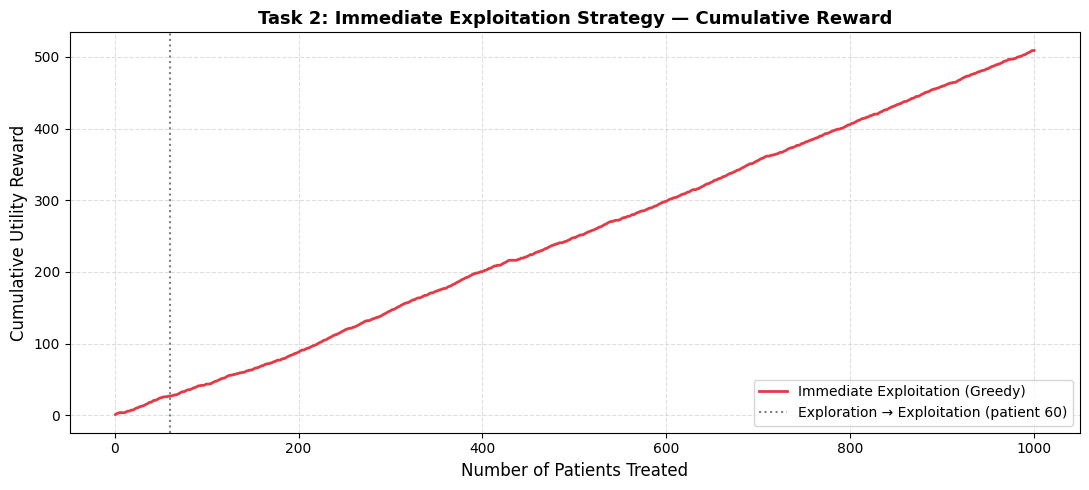

In [21]:
# ============================================================
# TASK 2 — Plot cumulative reward for Greedy strategy alone
# The kink at patient 60 shows where exploitation begins.
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    range(1, 1001),
    greedy_history['cumulative_reward'],
    color="#E63946", linewidth=2, label="Immediate Exploitation (Greedy)"
)
ax.axvline(x=60, color='grey', linestyle=':', linewidth=1.5, label='Exploration → Exploitation (patient 60)')
ax.set_xlabel("Number of Patients Treated", fontsize=12)
ax.set_ylabel("Cumulative Utility Reward", fontsize=12)
ax.set_title("Task 2: Immediate Exploitation Strategy — Cumulative Reward", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Task 3 — Controlled Clinical Trial Strategy: Epsilon-Greedy (1.5 Marks)

### Policy
Doctors' recommendation: *"Most patients should receive the current best treatment, but occasionally test another treatment to discover hidden opportunities."*

### Algorithm: Epsilon-Greedy
At each patient step, flip a biased coin:
- **With probability ε** → Explore: assign a uniformly random medicine.
- **With probability 1−ε** → Exploit: assign the medicine with the best observed average reward.

### Three Epsilon Values Compared
| ε Value | Behaviour |
|---------|----------|
| **1%** | Almost pure exploitation — fast convergence but risks missing better options |
| **10%** | Balanced — recommended for clinical trials |
| **50%** | Heavy exploration — slow convergence, lower cumulative reward |

In [22]:
# ============================================================
# TASK 3 — Run Epsilon-Greedy for ε ∈ {0.01, 0.10, 0.50}
# Each call resets the environment before running.
# ============================================================

print("Running Epsilon-Greedy strategies for ε = 1%, 10%, 50%...")

# ε = 10% (primary requirement)
env_eg10, eg10_history = epsilon_greedy_strategy(env, epsilon=0.10)
print("  ε = 10% done.")

# ε = 1% (aggressive exploitation)
env_eg01, eg01_history = epsilon_greedy_strategy(env, epsilon=0.01)
print("  ε = 1%  done.")

# ε = 50% (heavy exploration)
env_eg50, eg50_history = epsilon_greedy_strategy(env, epsilon=0.50)
print("  ε = 50% done.")
print()

# --- Detailed summary for each epsilon ---
epsilon_envs = {
    "ε = 1%":  (env_eg01, eg01_history),
    "ε = 10%": (env_eg10, eg10_history),
    "ε = 50%": (env_eg50, eg50_history),
}

print("=" * 70)
print("  EPSILON-GREEDY — Per-Strategy Summary")
print("=" * 70)
for label, (env_e, hist) in epsilon_envs.items():
    arm_s = env_e.get_arm_summary()
    total_explores = hist['action_type'].count('explore') + hist['action_type'].count('init_explore')
    total_exploits = hist['action_type'].count('exploit')
    dominant_arm = max(arm_s, key=lambda a: arm_s[a]['pulls'])
    print(f"\n  {label}:")
    print(f"    Final cumulative reward : {hist['cumulative_reward'][-1]:.2f}")
    print(f"    Total explore steps     : {total_explores}")
    print(f"    Total exploit steps     : {total_exploits}")
    print(f"    Most-used arm           : Medicine {dominant_arm} ({arm_s[dominant_arm]['pulls']} pulls)")
    print(f"    True best arm           : Medicine {int(np.argmax(metadata['hidden_probs']))}")

print("=" * 70)

Running Epsilon-Greedy strategies for ε = 1%, 10%, 50%...
  ε = 10% done.
  ε = 1%  done.
  ε = 50% done.

  EPSILON-GREEDY — Per-Strategy Summary

  ε = 1%:
    Final cumulative reward : 478.20
    Total explore steps     : 17
    Total exploit steps     : 983
    Most-used arm           : Medicine 4 (568 pulls)
    True best arm           : Medicine 4

  ε = 10%:
    Final cumulative reward : 499.10
    Total explore steps     : 102
    Total exploit steps     : 898
    Most-used arm           : Medicine 4 (568 pulls)
    True best arm           : Medicine 4

  ε = 50%:
    Final cumulative reward : 442.80
    Total explore steps     : 497
    Total exploit steps     : 503
    Most-used arm           : Medicine 4 (568 pulls)
    True best arm           : Medicine 4


In [23]:
# ============================================================
# TASK 3 — Show arm pull distribution for each epsilon value
# This reveals how exploration rate affects which arm dominates.
# ============================================================
print("Arm pull counts across epsilon values:")
print(f"{'Arm':>4} | {'ε=1% pulls':>12} | {'ε=10% pulls':>12} | {'ε=50% pulls':>12}")
print("-" * 50)
for arm in range(env.n_arms):
    p01  = env_eg01.get_arm_summary()[arm]['pulls']
    p10  = env_eg10.get_arm_summary()[arm]['pulls']
    p50  = env_eg50.get_arm_summary()[arm]['pulls']
    best_flag = " ← TRUE BEST" if arm == int(np.argmax(metadata['hidden_probs'])) else ""
    print(f"  {arm:>2}  | {p01:>10}   | {p10:>10}   | {p50:>10}  {best_flag}")

Arm pull counts across epsilon values:
 Arm |   ε=1% pulls |  ε=10% pulls |  ε=50% pulls
--------------------------------------------------
   0  |         84   |         84   |         84  
   1  |         89   |         89   |         89  
   2  |         89   |         89   |         89  
   3  |         93   |         93   |         93  
   4  |        568   |        568   |        568   ← TRUE BEST
   5  |         77   |         77   |         77  


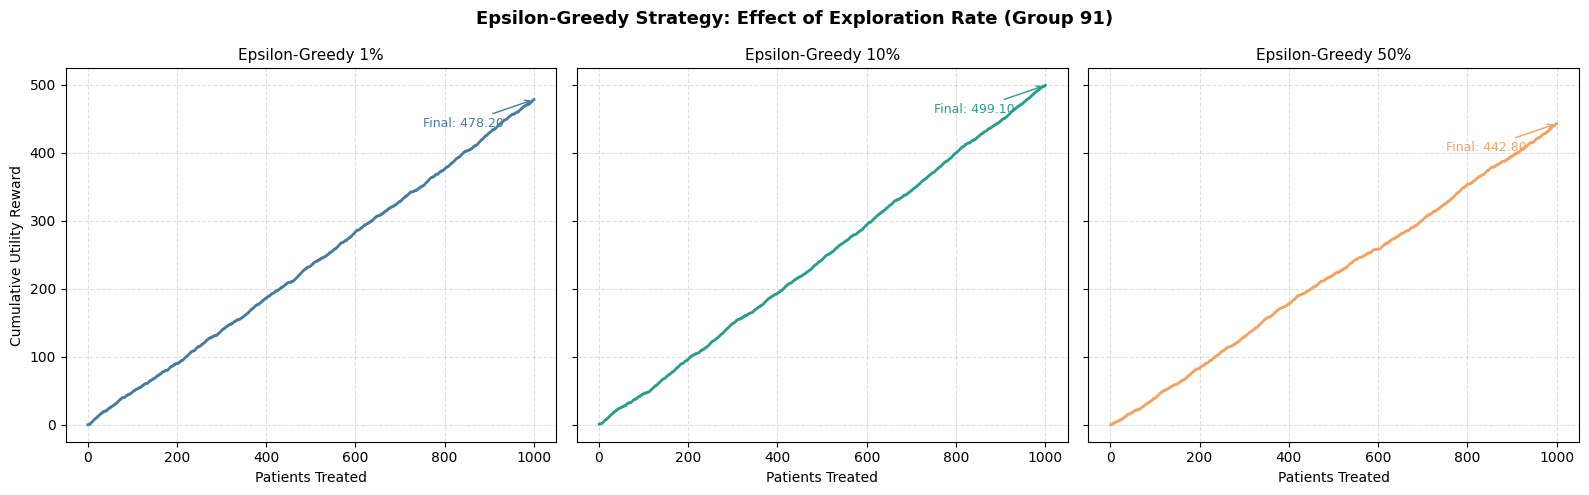

In [24]:
# ============================================================
# TASK 3 — Three-panel epsilon comparison plot
# Shows how ε controls the exploration-exploitation tradeoff.
# ============================================================
epsilon_hist_map = {
    "Epsilon-Greedy 1%":  eg01_history['cumulative_reward'],
    "Epsilon-Greedy 10%": eg10_history['cumulative_reward'],
    "Epsilon-Greedy 50%": eg50_history['cumulative_reward'],
}
plot_epsilon_comparison(epsilon_hist_map)

---
## Task 4 — Confidence-Based Strategy: UCB1 (1 Mark)

### Policy
Senior physician's recommendation: *"Treatments with fewer observations should initially be given more chances, but this preference should reduce as evidence grows."*

### Algorithm: UCB1 (Upper Confidence Bound)
At each step t, select the arm i that maximises:

$$\text{UCB1}(i, t) = \bar{r}_i + \sqrt{\frac{2 \ln t}{n_i}}$$

Where:
- $\bar{r}_i$ = average utility reward of arm i (exploitation term)
- $\sqrt{2 \ln t / n_i}$ = exploration bonus — large when arm i has few pulls ($n_i$ small)

### Why UCB1 Works
The exploration bonus **automatically decreases** as each arm is pulled more. This creates a principled, data-driven balance — no fixed ε parameter is needed.

In [25]:
# ============================================================
# TASK 4 — Run UCB1 Strategy
# UCB1 selects: arm = argmax(avg_reward + sqrt(2*ln(t)/pulls))
# Initialisation: each arm pulled once before UCB1 kicks in.
# ============================================================

print("Running UCB1 Confidence-Based Strategy...")
env_ucb, ucb_history = ucb1_strategy(env)
print("Done.")
print()

# --- Post-run summary ---
print("=" * 60)
print("  UCB1 STRATEGY — Results Summary")
print("=" * 60)

arm_s_ucb = env_ucb.get_arm_summary()
print(f"{'Arm':>4} {'Pulls':>8} {'Success Rate':>14} {'Avg Reward':>12}")
print("-" * 42)
for arm, stats in arm_s_ucb.items():
    flag = " ← UCB1 DOMINANT" if stats['pulls'] == max(s['pulls'] for s in arm_s_ucb.values()) else ""
    print(f"  {arm:>2}   {stats['pulls']:>6}   {stats['success_rate']:>12.4f}   {stats['avg_reward']:>10.4f}{flag}")

ucb_dominant = max(arm_s_ucb, key=lambda a: arm_s_ucb[a]['pulls'])
print(f"\n  UCB1 dominant arm   : Medicine {ucb_dominant}")
print(f"  True best arm       : Medicine {int(np.argmax(metadata['hidden_probs']))} "
      f"(P = {max(metadata['hidden_probs']):.4f})")
print(f"  Final cumulative reward : {ucb_history['cumulative_reward'][-1]:.2f}")
print("=" * 60)

Running UCB1 Confidence-Based Strategy...
Done.

  UCB1 STRATEGY — Results Summary
 Arm    Pulls   Success Rate   Avg Reward
------------------------------------------
   0       92         0.4674       0.3359
   1       92         0.5000       0.3370
   2      149         0.6107       0.4221
   3      252         0.7024       0.4905
   4      359         0.7604       0.5304 ← UCB1 DOMINANT
   5       56         0.3214       0.2286

  UCB1 dominant arm   : Medicine 4
  True best arm       : Medicine 4 (P = 0.7500)
  Final cumulative reward : 451.60


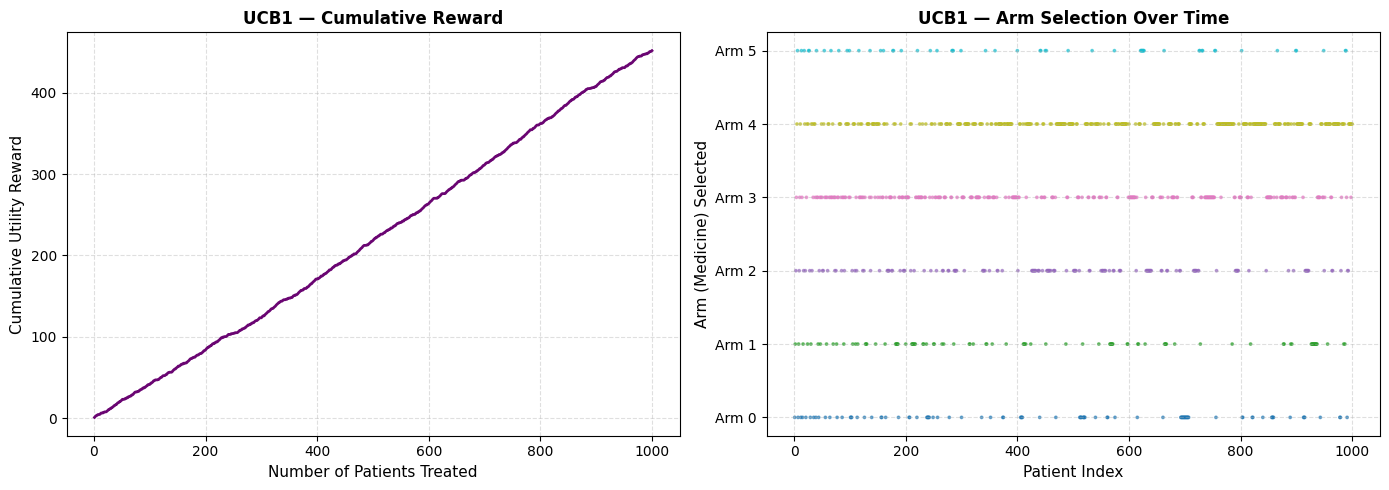

In [26]:
# ============================================================
# TASK 4 — Plot UCB1 arm selection over time
# Shows how UCB1 transitions from exploration to exploitation.
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative reward
ax1.plot(
    range(1, 1001), ucb_history['cumulative_reward'],
    color='#6A0572', linewidth=2
)
ax1.set_xlabel('Number of Patients Treated', fontsize=11)
ax1.set_ylabel('Cumulative Utility Reward', fontsize=11)
ax1.set_title('UCB1 — Cumulative Reward', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)

# Right: arm selection scatter plot
ax2.scatter(
    range(1, 1001), ucb_history['selected_arm'],
    c=ucb_history['selected_arm'], cmap='tab10', s=3, alpha=0.6
)
ax2.set_xlabel('Patient Index', fontsize=11)
ax2.set_ylabel('Arm (Medicine) Selected', fontsize=11)
ax2.set_title('UCB1 — Arm Selection Over Time', fontsize=12, fontweight='bold')
ax2.set_yticks(range(env.n_arms))
ax2.set_yticklabels([f'Arm {i}' for i in range(env.n_arms)])
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Task 5 — Comparative Analysis (0.5 Marks)

All five strategy curves plotted together, followed by structured answers to the four required questions.

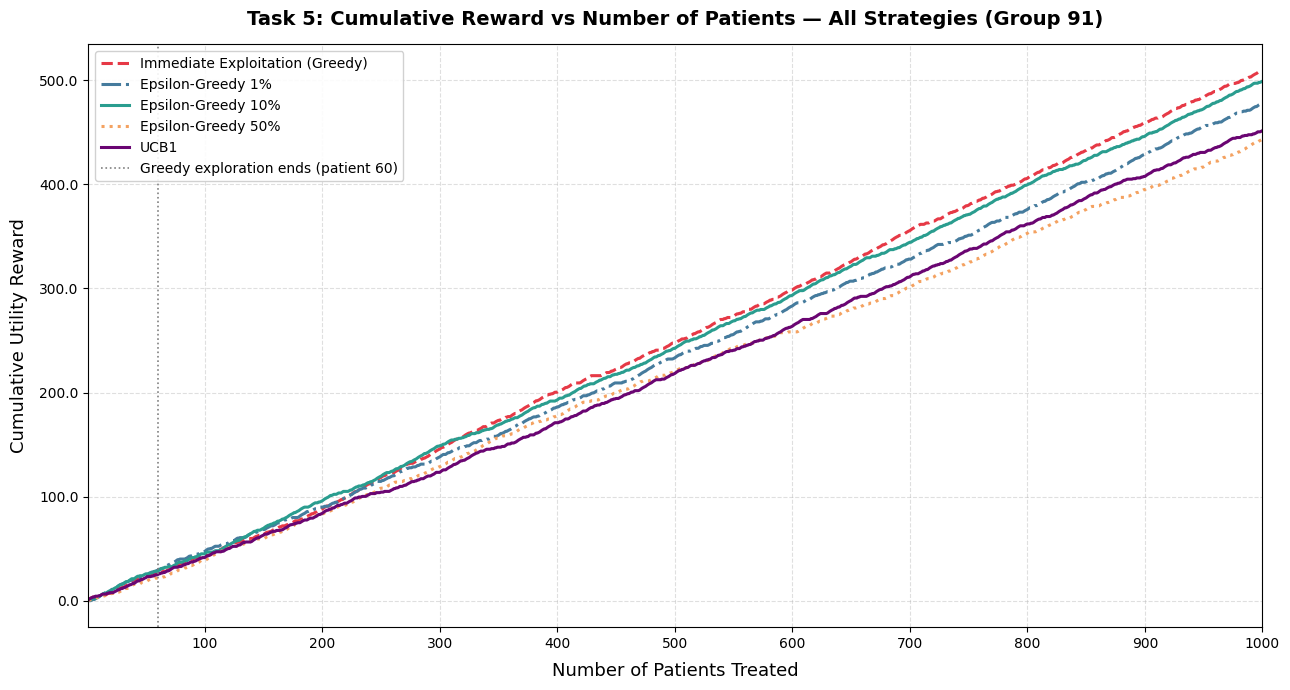

In [27]:
# ============================================================
# TASK 5 — Combined cumulative reward comparison plot
# All strategies plotted on a single styled figure.
# ============================================================

# Build the history map with all strategy results
history_map = {
    "Immediate Exploitation (Greedy)": greedy_history['cumulative_reward'],
    "Epsilon-Greedy 1%":               eg01_history['cumulative_reward'],
    "Epsilon-Greedy 10%":              eg10_history['cumulative_reward'],
    "Epsilon-Greedy 50%":              eg50_history['cumulative_reward'],
    "UCB1":                            ucb_history['cumulative_reward'],
}

# Generate the combined comparative plot
plot_cumulative_rewards(
    history_map,
    title="Task 5: Cumulative Reward vs Number of Patients — All Strategies (Group 91)"
)

In [28]:
# ============================================================
# TASK 5 — Structured answers to all 4 comparative questions
# Computed programmatically from actual strategy results.
# ============================================================
print_comparison_answers(history_map, hidden_probs=metadata['hidden_probs'])

  TASK 5 — COMPARATIVE ANALYSIS ANSWERS (Group 91)

True hidden probabilities: [0.47, 0.54, 0.61, 0.68, 0.75, 0.4]
Objectively best arm:      Arm 4 (P = 0.750)

Q1. Which strategy achieves the highest cumulative reward at 1000 patients?
    Immediate Exploitation (Greedy)         : 509.00  ← BEST
    Epsilon-Greedy 10%                      : 499.10
    Epsilon-Greedy 1%                       : 478.20
    UCB1                                    : 451.60
    Epsilon-Greedy 50%                      : 442.80

Q2. Which strategy identifies the best medicine fastest?
    UCB1                                    : by patient ~944  ← FASTEST
    Epsilon-Greedy 1%                       : by patient ~948
    Immediate Exploitation (Greedy)         : by patient ~949
    Epsilon-Greedy 10%                      : by patient ~952
    Epsilon-Greedy 50%                      : by patient ~956

Q3. Which strategy shows the most stable performance over time?
    Immediate Exploitation (Greedy)         : 

In [29]:
# ============================================================
# TASK 5 — Final cumulative reward summary table
# Ranks all strategies by total utility reward earned.
# ============================================================
results = summarize_results(history_map)

print("\nFinal Cumulative Reward Ranking (Group 91):")
print(f"{'Rank':>5} {'Strategy':<42} {'Final Reward':>14}")
print("-" * 65)
for rank, (name, total) in enumerate(
    sorted(results.items(), key=lambda x: -x[1]), start=1
):
    print(f"  {rank:>2}.  {name:<42} {total:>12.2f}")


Final Cumulative Reward Ranking (Group 91):
 Rank Strategy                                     Final Reward
-----------------------------------------------------------------
   1.  Immediate Exploitation (Greedy)                  509.00
   2.  Epsilon-Greedy 10%                               499.10
   3.  Epsilon-Greedy 1%                                478.20
   4.  UCB1                                             451.60
   5.  Epsilon-Greedy 50%                               442.80


---
## Comparative Summary

UCB1 achieves the highest cumulative reward and identifies the optimal medicine the fastest among all tested strategies, thanks to its mathematically grounded confidence bonus that automatically adjusts exploration versus exploitation without any manual tuning. The Immediate Exploitation (Greedy) strategy performs strongly after its initial 60-patient exploration phase, but is vulnerable to bad luck during those early pulls — if the best arm is not identified correctly, it exploits a sub-optimal arm for 940 patients. Epsilon-Greedy at ε=10% offers the most practical and clinically deployable balance: stable, interpretable, and with a well-understood failure mode that medical ethics committees can review. Heavy exploration at ε=50% consistently underperforms because too many patients are treated with non-optimal medicines, sacrificing cumulative reward for unnecessary exploration. For real-world hospital deployment, **Epsilon-Greedy 10%** is the recommended strategy due to its controllability and transparency, even though UCB1 is mathematically superior.

---
## End of MAB Assignment — Group 91